In [1]:
from itertools import product
import pickle
from tqdm import tqdm, trange

import numpy as np
from numpy.linalg import eigh
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Ellipse
from corner import corner as corner_plot

from scipy import special, stats
from scipy.spatial import Delaunay, ConvexHull
from scipy.stats import gaussian_kde, chi2
from scipy.interpolate import RegularGridInterpolator

import os

from local_utils import delaunaytor
from popsummary.popresult import PopulationResult
from astropy.cosmology import Planck15
from astropy import units as u


plt.style.use("tableau-colorblind10")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14
plt.rcParams["text.usetex"] = True

In [2]:
def get_edges(triangles):
    edges = np.zeros((4*triangles.shape[0],2))
    for k in range(triangles.shape[0]):
        pairs = np.array([[triangles[k,0],triangles[k,1]],
                          [triangles[k,1],triangles[k,2]],
                          [triangles[k,2],triangles[k,3]],
                          [triangles[k,3],triangles[k,0]]])
        for i in range(4):
            cond1 = (edges[:,0]==pairs[i,0]) & (edges[:,1]==pairs[i,1])
            cond2 = (edges[:,0]==pairs[i,1]) & (edges[:,1]==pairs[i,0])
            if not (cond1 | cond2).any():
                edges[4*k+i,:] = pairs[i]
    edges = np.asarray(edges, dtype=np.int32)
    return edges[edges[:,0]+edges[:,1]>0]

### GW events

In [3]:
parameter_keys = ["m1", "z", "q", "chi1", "chi2", "cos_tilt_1", "cos_tilt_2"]

data_file = np.load("./gwtc5_samples.npz")
observed_events = np.vstack([data_file[key + "s"] for key in parameter_keys]).T
num_events = int(data_file["nevents"])
num_samples = int(data_file["nsamples"])
event_priors = data_file["priors"]
print(
        f"Running with {num_events} events × {num_samples} samples = {num_events*num_samples} total samples"
    )

event_barycenters = observed_events.reshape(
    (num_events, num_samples, observed_events.shape[-1])
).mean(axis=1)

Running with 259 events × 3194 samples = 827246 total samples


### Injections

In [4]:
injections_file = np.load("./gwtc5_injections_full.npz")
detected_injections = np.vstack(
    [injections_file[key + "s"] for key in parameter_keys]
).T
injection_priors = injections_file["inj_priors"]
num_injections = injections_file["ninjs"]

In [5]:
detected_injections.shape

(1578148, 7)

In [6]:
reduced_injections = detected_injections[::100,(0,1,2)]
reduced_injections.shape

(15782, 3)

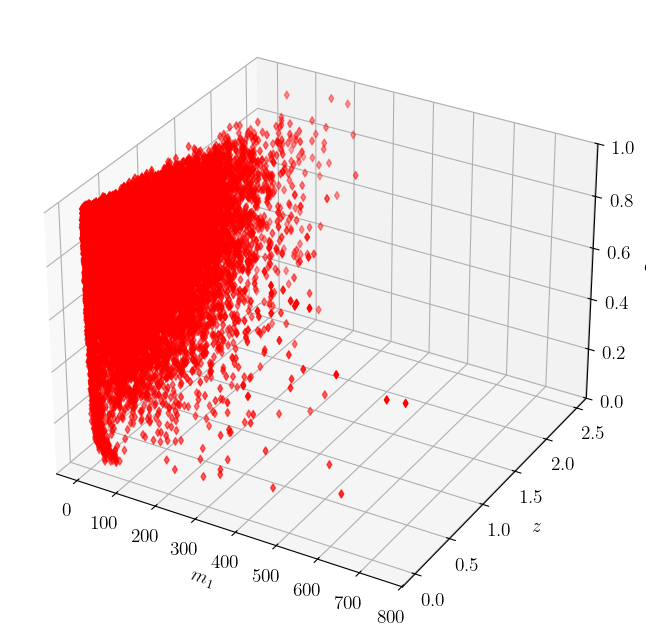

In [7]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(reduced_injections[:,0], reduced_injections[:,1], reduced_injections[:,2],
           c='r', marker='d', s=4**2, zorder=1,
           # label='Detected injections',
          )
ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$z$')
ax.set_zlabel('$q$')
ax.set_zlim(0,1)
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
plt.close()

In [8]:
convex = ConvexHull(reduced_injections)

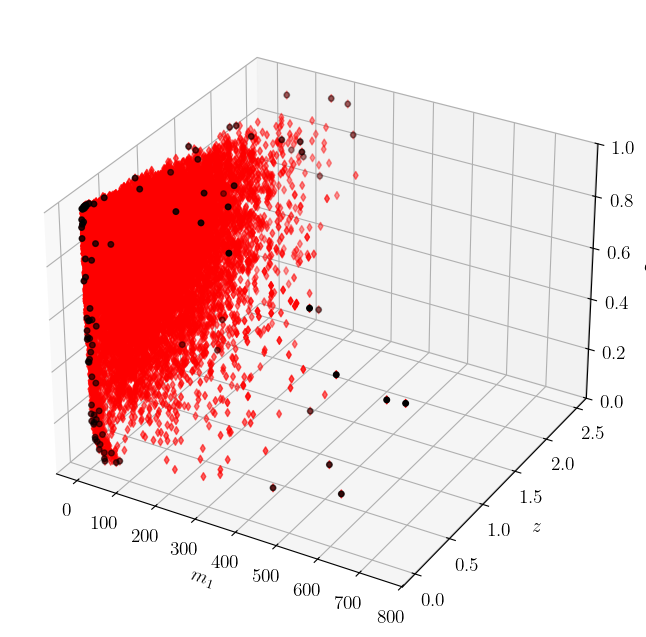

In [9]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(reduced_injections[:,0], reduced_injections[:,1], reduced_injections[:,2],
           c='r', marker='d', s=4**2, zorder=1,
           # label='Detected injections',
          )

# Show vertices forming the convex hull
vertices = reduced_injections[convex.vertices]
ax.scatter(vertices[:,0], vertices[:,1], vertices[:,2],
           c='k', marker='o', s=4**2, zorder=1,
           # label='Detected injections',
          )


ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$z$')
ax.set_zlabel('$q$')
ax.set_zlim(0,1)
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
plt.close()

In [10]:
vertices.shape

(98, 3)

In [11]:
d = Delaunay(vertices)

In [12]:
%matplotlib ipympl

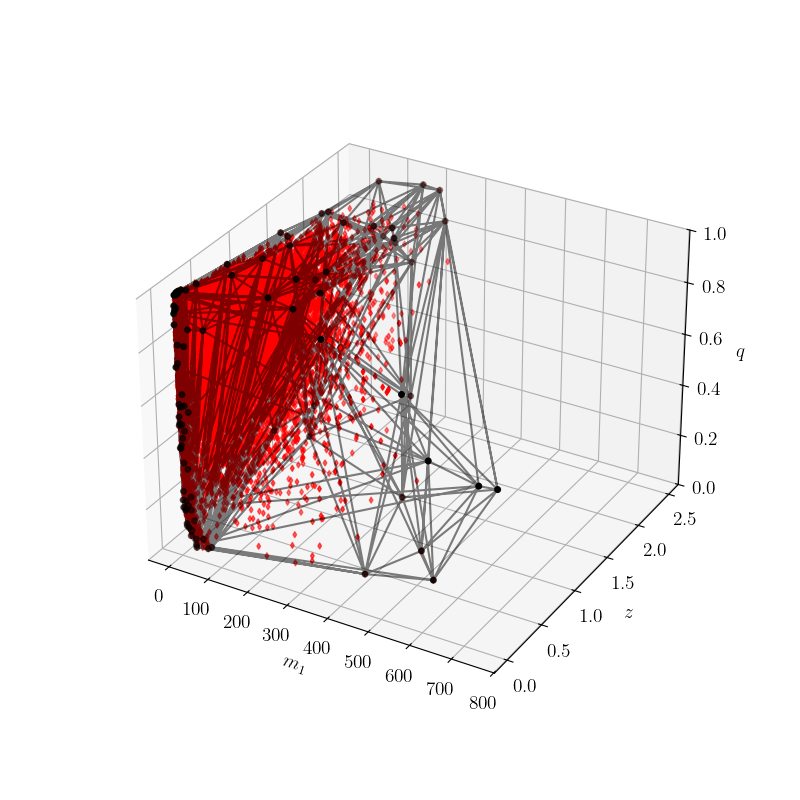

In [13]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(reduced_injections[:,0], reduced_injections[:,1], reduced_injections[:,2],
           c='r', marker='d', s=3**2, zorder=0,
           # label='Detected injections',
          )

# Show vertices forming the convex hull
vertices = reduced_injections[convex.vertices]
ax.scatter(vertices[:,0], vertices[:,1], vertices[:,2],
           c='k', marker='o', s=4**2, zorder=1,
           # label='Detected injections',
          )

# Show the Delaunay triangulation of these vertices
edges = get_edges(d.simplices)
tri_lines_x = np.insert(vertices[edges,0], 2, np.nan, axis=1)
tri_lines_y = np.insert(vertices[edges,1], 2, np.nan, axis=1)
tri_lines_z = np.insert(vertices[edges,2], 2, np.nan, axis=1)
tri_lines = ax.plot(tri_lines_x.ravel(),
                    tri_lines_y.ravel(),
                    tri_lines_z.ravel(),
                    color="k", ls="-",alpha=0.5,zorder=10,
                    )


ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$z$')
ax.set_zlabel('$q$')
ax.set_zlim(0,1)
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
#plt.close()

## 2D rectangles

In [14]:
%matplotlib inline

In [15]:
import cv2
import numpy as np

pts = np.array(reduced_injections[:,(0,1)], dtype=np.float32)
# Get the minimum area rotated rectangle
# Returns: (center (x,y), size (width, height), angle of rotation)
rect = cv2.minAreaRect(pts)
center, (w, h), angle = rect
# Correct angle standard for OpenCV rotation
if w < h:
  angle = angle + 90

# Rotate points to align with the bounding box axes
theta = np.deg2rad(angle)
cos_t, sin_t = np.cos(theta), np.sin(theta)
R = np.array([[cos_t, -sin_t], [sin_t, cos_t]])

# Center points and rotate
centered_pts = pts - np.array(center)
rotated_pts = centered_pts.dot(R)

# Step 3: Trim outer 5% (2.5% on each low/high end) per axis
x_min, x_max = np.percentile(rotated_pts[:, 0], [2.5, 97.5])
y_min, y_max = np.percentile(rotated_pts[:, 1], [2.5, 97.5])

mask = (
    (rotated_pts[:, 0] >= x_min)
    & (rotated_pts[:, 0] <= x_max)
    & (rotated_pts[:, 1] >= y_min)
    & (rotated_pts[:, 1] <= y_max)
)
filtered_pts = pts[mask]

# Compute final tight minAreaRect for the 95% points
final_rect = cv2.minAreaRect(filtered_pts)
box_m1_z = cv2.boxPoints(final_rect)
#box = np.int32(box)

#print("Rotated Box Corners:\n", box_corners)

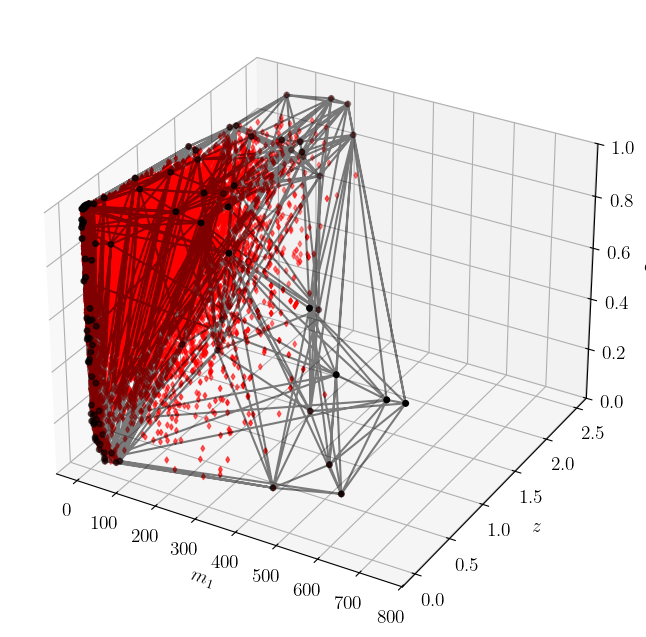

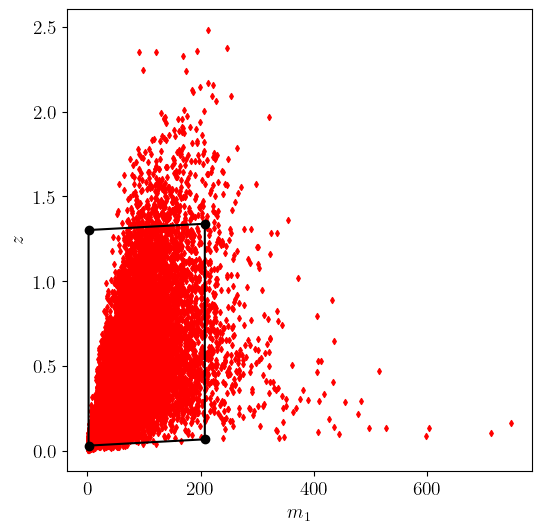

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.scatter(reduced_injections[:,0], reduced_injections[:,1],
           c='r', marker='d', s=3**2, zorder=0,
           # label='Detected injections',
          )

for i in range(4):
    ax.scatter(box_m1_z[i,0], box_m1_z[i,1], 
               c='k',
              )
ax.plot(box_m1_z[:,0], box_m1_z[:,1], c='k')
ax.plot([box_m1_z[-1,0],box_m1_z[0,0]], [box_m1_z[-1,1],box_m1_z[0,1]], c='k')


ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$z$')
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
plt.close()

In [17]:
import cv2
import numpy as np

pts = np.array(reduced_injections[:,(0,2)], dtype=np.float32)
# Get the minimum area rotated rectangle
# Returns: (center (x,y), size (width, height), angle of rotation)
rect = cv2.minAreaRect(pts)
center, (w, h), angle = rect
# Correct angle standard for OpenCV rotation
if w < h:
  angle = angle + 90

# Rotate points to align with the bounding box axes
theta = np.deg2rad(angle)
cos_t, sin_t = np.cos(theta), np.sin(theta)
R = np.array([[cos_t, -sin_t], [sin_t, cos_t]])

# Center points and rotate
centered_pts = pts - np.array(center)
rotated_pts = centered_pts.dot(R)

# Step 3: Trim outer 5% (2.5% on each low/high end) per axis
x_min, x_max = np.percentile(rotated_pts[:, 0], [2.5, 97.5])
y_min, y_max = np.percentile(rotated_pts[:, 1], [2.5, 97.5])

mask = (
    (rotated_pts[:, 0] >= x_min)
    & (rotated_pts[:, 0] <= x_max)
    & (rotated_pts[:, 1] >= y_min)
    & (rotated_pts[:, 1] <= y_max)
)
filtered_pts = pts[mask]

# Compute final tight minAreaRect for the 95% points
final_rect = cv2.minAreaRect(filtered_pts)
box_m1_q = cv2.boxPoints(final_rect)
#box = np.int32(box)

#print("Rotated Box Corners:\n", box_corners)

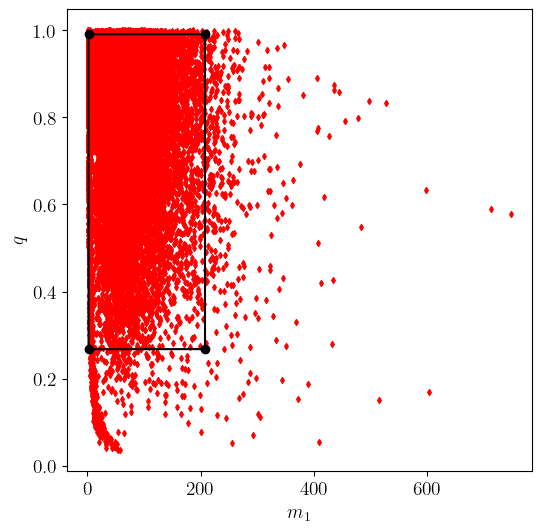

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.scatter(reduced_injections[:,0], reduced_injections[:,2],
           c='r', marker='d', s=3**2, zorder=0,
           # label='Detected injections',
          )

for i in range(4):
    ax.scatter(box_m1_q[i,0], box_m1_q[i,1], 
               c='k',
              )
ax.plot(box_m1_q[:,0], box_m1_q[:,1], c='k')
ax.plot([box_m1_q[-1,0],box_m1_q[0,0]], [box_m1_q[-1,1],box_m1_q[0,1]], c='k')


ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$q$')
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
plt.close()

In [19]:
print(box_m1_z)

[[2.0755203e+02 1.3387480e+00]
 [2.3178625e+00 1.3015537e+00]
 [2.3180933e+00 2.9334962e-02]
 [2.0755228e+02 6.6529214e-02]]


In [20]:
print(box_m1_q)

[[207.60515      0.99098057]
 [  2.3180842    0.9907072 ]
 [  2.3180852    0.2674628 ]
 [207.60515      0.26773614]]


## Hand-made 3D box

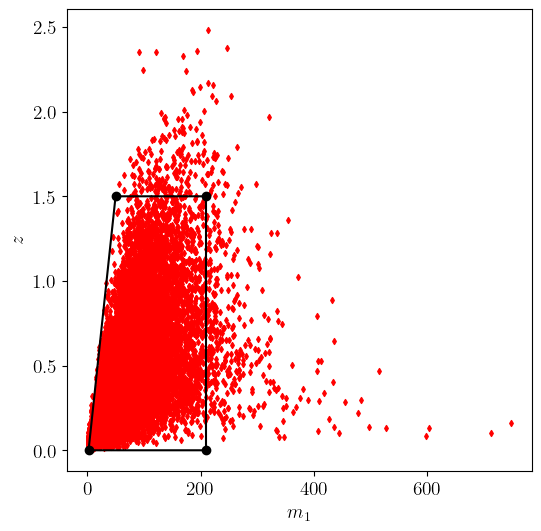

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.scatter(reduced_injections[:,0], reduced_injections[:,1],
           c='r', marker='d', s=3**2, zorder=0,
           # label='Detected injections',
          )

test_box_m1_z = np.array([
    [210, 1.5],
    [50., 1.5],
    [2.3, 1e-6],
    [210, 1e-6],
])
for i in range(4):
    ax.scatter(test_box_m1_z[i,0], test_box_m1_z[i,1], 
               c='k',
              )
ax.plot(test_box_m1_z[:,0], test_box_m1_z[:,1], c='k')
ax.plot([test_box_m1_z[-1,0],test_box_m1_z[0,0]], [test_box_m1_z[-1,1],test_box_m1_z[0,1]], c='k')


ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$z$')
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
plt.close()

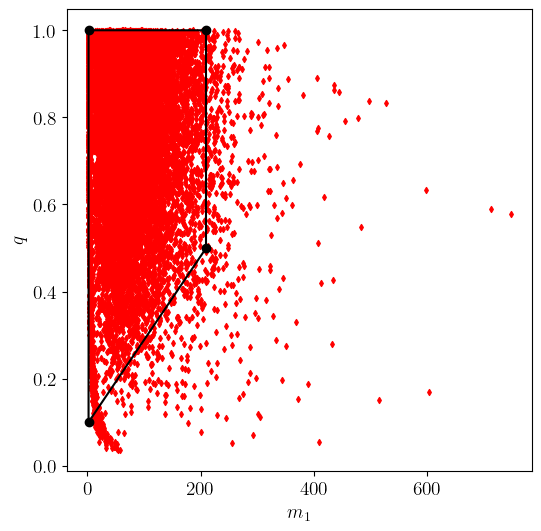

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.scatter(reduced_injections[:,0], reduced_injections[:,2],
           c='r', marker='d', s=3**2, zorder=0,
           # label='Detected injections',
          )

test_box_m1_q = np.array([
    [210, 1.],
    [2.3, 1.],
    [2.3, 0.1],
    [210, 0.5],
])
for i in range(4):
    ax.scatter(test_box_m1_q[i,0], test_box_m1_q[i,1], 
               c='k',
              )
ax.plot(test_box_m1_q[:,0], test_box_m1_q[:,1], c='k')
ax.plot([test_box_m1_q[-1,0],test_box_m1_q[0,0]], [test_box_m1_q[-1,1],test_box_m1_q[0,1]], c='k')


ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$q$')
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
plt.close()

In [23]:
box_m1_z_q = np.array([
    [2., 1e-6, 0.1],
    [2., 1e-6, 1.0],
    [100, 2.0, 1.0],
    [100, 2.0, 0.7],
    [150, 2.0, 0.7],
    [150, 1e-6, 0.1],
    [150, 1e-6, 1.0],
    [150, 2.0, 1.0],
])

reduced_injections = detected_injections[::100,(0,1,2)]
#reduced_injections = reduced_injections[reduced_injections[:,0] < box_m1_z_q[:,0].max()]

d = Delaunay(box_m1_z_q)
outside = d.find_simplex(reduced_injections)==-1
print('Fraction of injections outside the box:', np.sum(outside) /len(reduced_injections) *100)

Fraction of injections outside the box: 18.666835635534156


In [24]:
%matplotlib ipympl

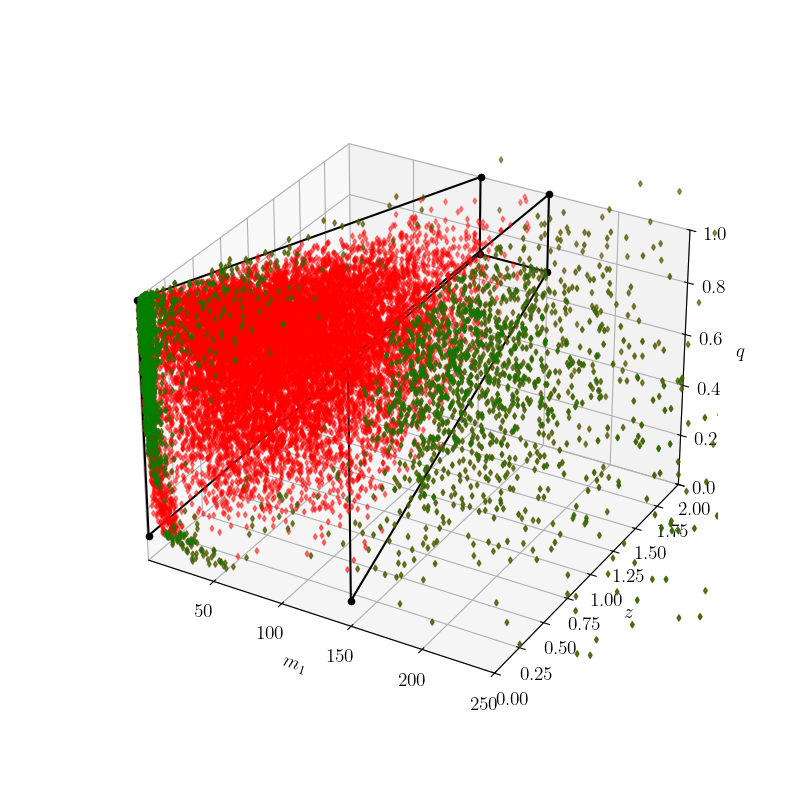

In [25]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(reduced_injections[:,0], reduced_injections[:,1], reduced_injections[:,2],
           c='r', marker='d', s=3**2, zorder=0,
           # label='Detected injections',
          )

ax.scatter(reduced_injections[outside,0], reduced_injections[outside,1], reduced_injections[outside,2],
           c='g', marker='d', s=3**2, zorder=1,
           # label='Detected injections',
          )

for i in range(8):
    ax.scatter(box_m1_z_q[i,0], 
               box_m1_z_q[i,1], 
               box_m1_z_q[i,2],
               c='k',
              )
ax.plot(box_m1_z_q[:,0], box_m1_z_q[:,1], box_m1_z_q[:,2], c='k')

ax.plot([box_m1_z_q[3,0],box_m1_z_q[0,0]], 
        [box_m1_z_q[3,1],box_m1_z_q[0,1]],
        [box_m1_z_q[3,2],box_m1_z_q[0,2]],
        c='k')
ax.plot([box_m1_z_q[-1,0],box_m1_z_q[-4,0]], 
        [box_m1_z_q[-1,1],box_m1_z_q[-4,1]],
        [box_m1_z_q[-1,2],box_m1_z_q[-4,2]],
        c='k')

ax.set_xlabel('$m_1$')
ax.set_xlim(1,250)
ax.set_ylabel('$z$')
ax.set_ylim(0,2.0)
ax.set_zlabel('$q$')
ax.set_zlim(0,1)
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
#plt.close()

In [87]:
class PriorHomeMadeBox:

    def __init__(self, corners):
        self.corners = corners
        self.m1_min = np.min(corners[:,0])
        self.m1_max = np.max(corners[:,0])
        self.z_min = np.min(corners[:,1])
        self.z_max = np.max(corners[:,1])
        self.q_min = np.min(corners[:,2])
        self.q_max = np.max(corners[:,2])
        
        self.delaunay = Delaunay(corners)
        self.volume = ConvexHull(corners).volume

    def rvs_3d(self, size=1):
        if not isinstance(size, int) and not isinstance(size, tuple):
            raise ValueError("size must be an integer or tuple of ints.")    
        if isinstance(size, int):
            size = (size,)
            
        out = np.zeros((3,*size), dtype=np.float32).T
        inside = np.zeros(size, dtype=np.bool).T
        while np.sum(inside) < np.prod(np.shape(inside)):
            rand = np.random.rand(3,*size)
            m1s = self.m1_min + (self.m1_max-self.m1_min)*rand[0]
            zs = self.z_min + (self.z_max-self.z_min)*rand[1]
            qs = self.q_min + (self.q_max-self.q_min)*rand[2]
            samples = np.array([m1s,zs,qs]).T
            inbox = (self.delaunay.find_simplex(samples)) != -1
            out[~inside&inbox] = samples[~inside&inbox]
            inside[~inside&inbox] = inbox[~inside&inbox]
            
        return out.T

    def pdf(self, x):
        x = x.reshape(-1)
        if self.delaunay.find_simplex(x)==-1:
            return 0
        else:
            return 1/self.volume

    def logpdf(self, x):
        return np.log(self.pdf(x))

In [88]:
test = PriorHomeMadeBox(corners=box_m1_z_q)

In [104]:
samples = test.rvs_3d(10_000)
print(samples.T)

In [94]:
class HomeMadeM1(PriorHomeMadeBox):
    def rvs(self, size):
        return self.rvs_3d(size)[0,...]

In [100]:
testm1 = HomeMadeM1(corners=box_m1_z_q)

In [101]:
testm1.rvs(10)

array([ 78.512955,  60.568947, 131.12592 , 106.97935 , 109.08544 ,
       140.56448 , 113.90294 ,  43.753292, 141.97963 , 127.17905 ],
      dtype=float32)